# Week 4 — Drift Simulation

**Person 2**

Systematic evaluation of model performance under increasing:
- Blur
- Rotation
- Brightness
- Noise

The experiment uses the real held-out test dataset and measures where
accuracy begins to degrade as drift strength increases.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject


In [3]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

from src.predict import CastingPredictor

In [4]:
# Load the processed test manifest
manifest_path = PROJECT_ROOT / "data" / "processed" / "manifest.csv"

manifest = pd.read_csv(manifest_path)

# Keep only valid images from the real test split
test_df = manifest[
    (manifest["split"] == "test") &
    (manifest["is_valid"] == True)
].copy()

print(f"Total test images: {len(test_df)}")
print("\nClass distribution:")
print(test_df["label_name"].value_counts())

Total test images: 711

Class distribution:
label_name
def_front    449
ok_front     262
Name: count, dtype: int64


In [6]:
# Load the trained ResNet18 predictor
model_path = PROJECT_ROOT / "models" / "resnet18_transfer_best.pth"

predictor = CastingPredictor(model_path=str(model_path))

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
# Evaluate the model on the untouched test images

correct = 0
total = 0

for _, row in test_df.iterrows():

    image_path = PROJECT_ROOT / row["processed_filepath"].replace(
        "..\\", ""
    ).replace("\\", "/")

    # Load image
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    # Predict
    result = predictor.predict(image_bytes)

    predicted_label = 1 if result["is_defective"] else 0
    true_label = int(row["label"])

    if predicted_label == true_label:
        correct += 1

    total += 1

baseline_accuracy = correct / total

print("=" * 45)
print("BASELINE MODEL PERFORMANCE")
print("=" * 45)
print(f"Total images:          {total}")
print(f"Correct predictions:   {correct}")
print(f"Incorrect predictions: {total - correct}")
print(f"Baseline accuracy:     {baseline_accuracy:.4%}")

BASELINE MODEL PERFORMANCE
Total images:          711
Correct predictions:   693
Incorrect predictions: 18
Baseline accuracy:     97.4684%


In [8]:
from PIL import ImageFilter

# Blur strengths to test
blur_strengths = [0, 1, 2, 3, 5, 7]

blur_results = []

for strength in blur_strengths:

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        image_path = PROJECT_ROOT / row["processed_filepath"].replace(
            "..\\", ""
        ).replace("\\", "/")

        # Load original image
        image = Image.open(image_path).convert("RGB")

        # Apply Gaussian blur
        if strength > 0:
            image = image.filter(
                ImageFilter.GaussianBlur(radius=strength)
            )

        # Convert image to bytes
        import io

        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        image_bytes = buffer.getvalue()

        # Predict
        result = predictor.predict(image_bytes)

        predicted_label = 1 if result["is_defective"] else 0
        true_label = int(row["label"])

        if predicted_label == true_label:
            correct += 1

        total += 1

    accuracy = correct / total

    blur_results.append({
        "blur_strength": strength,
        "accuracy": accuracy
    })

    print(
        f"Blur strength {strength}: "
        f"{accuracy:.4%} accuracy "
        f"({correct}/{total})"
    )

blur_results_df = pd.DataFrame(blur_results)

Blur strength 0: 97.4684% accuracy (693/711)
Blur strength 1: 94.6554% accuracy (673/711)
Blur strength 2: 88.3263% accuracy (628/711)
Blur strength 3: 85.3727% accuracy (607/711)
Blur strength 5: 76.3713% accuracy (543/711)
Blur strength 7: 75.2461% accuracy (535/711)


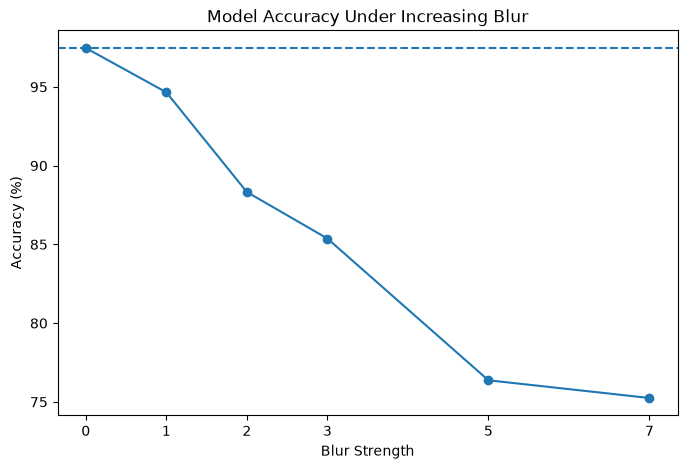

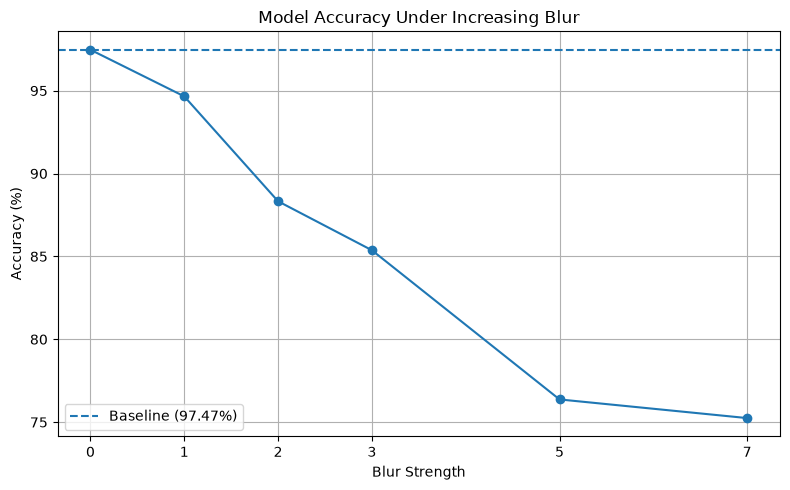

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_blur_accuracy.png


C:\Users\HP\AppData\Local\Temp\ipykernel_13368\1389966702.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


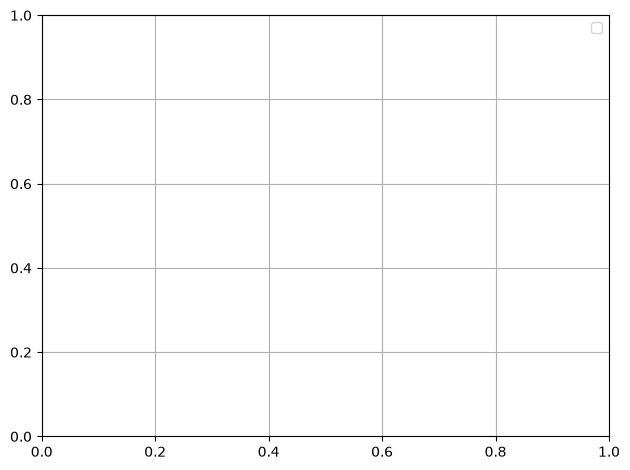

In [11]:
# Plot blur strength vs accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    blur_results_df["blur_strength"],
    blur_results_df["accuracy"] * 100,
    marker="o"
)

plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Blur Strength")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Increasing Blur")
plt.xticks(blur_strengths)# Save and display the blur accuracy plot

plt.figure(figsize=(8, 5))

plt.plot(
    blur_results_df["blur_strength"],
    blur_results_df["accuracy"] * 100,
    marker="o"
)

plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Blur Strength")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Increasing Blur")
plt.xticks(blur_strengths)
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save the figure
output_path = PROJECT_ROOT / "reports" / "figures" / "drift_blur_accuracy.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
import io

# Rotation angles to test
rotation_angles = [0, 2, 5, 10, 15, 20]

rotation_results = []

for angle in rotation_angles:

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        image_path = PROJECT_ROOT / row["processed_filepath"].replace(
            "..\\", ""
        ).replace("\\", "/")

        image = Image.open(image_path).convert("RGB")

        # Apply rotation
        if angle != 0:
            image = image.rotate(
                angle,
                resample=Image.Resampling.BILINEAR,
                expand=False
            )

        # Convert image to bytes
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        image_bytes = buffer.getvalue()

        # Predict
        result = predictor.predict(image_bytes)

        predicted_label = 1 if result["is_defective"] else 0
        true_label = int(row["label"])

        if predicted_label == true_label:
            correct += 1

        total += 1

    accuracy = correct / total

    rotation_results.append({
        "rotation_angle": angle,
        "accuracy": accuracy
    })

    print(
        f"Rotation {angle}°: "
        f"{accuracy:.4%} accuracy "
        f"({correct}/{total})"
    )

rotation_results_df = pd.DataFrame(rotation_results)

Rotation 0°: 97.4684% accuracy (693/711)
Rotation 2°: 92.9677% accuracy (661/711)
Rotation 5°: 89.7328% accuracy (638/711)
Rotation 10°: 85.9353% accuracy (611/711)
Rotation 15°: 74.2616% accuracy (528/711)
Rotation 20°: 89.0295% accuracy (633/711)


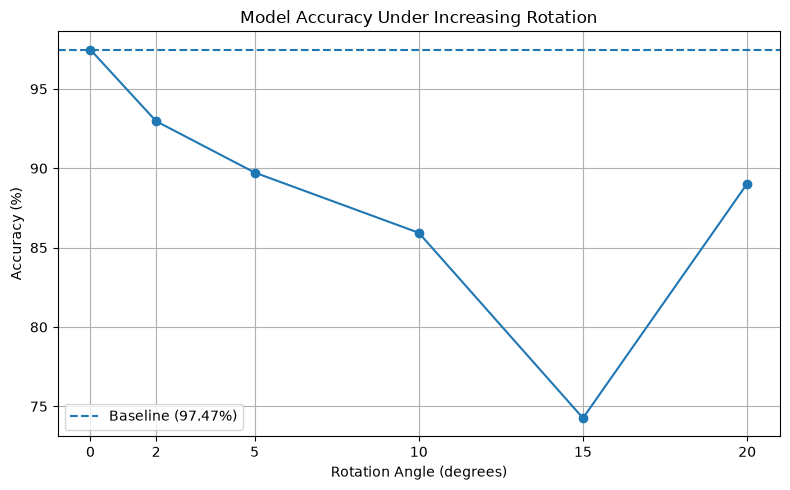

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_rotation_accuracy.png


In [13]:
# Plot and save rotation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    rotation_results_df["rotation_angle"],
    rotation_results_df["accuracy"] * 100,
    marker="o"
)

plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Increasing Rotation")
plt.xticks(rotation_angles)
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save the figure
output_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "drift_rotation_accuracy.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")

In [14]:
# Brightness factors to test
brightness_factors = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5]

brightness_results = []

for factor in brightness_factors:

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        image_path = PROJECT_ROOT / row["processed_filepath"].replace(
            "..\\", ""
        ).replace("\\", "/")

        # Load original image
        image = Image.open(image_path).convert("RGB")

        # Apply brightness adjustment
        image = ImageEnhance.Brightness(image).enhance(factor)

        # Convert image to bytes
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        image_bytes = buffer.getvalue()

        # Predict
        result = predictor.predict(image_bytes)

        predicted_label = 1 if result["is_defective"] else 0
        true_label = int(row["label"])

        if predicted_label == true_label:
            correct += 1

        total += 1

    accuracy = correct / total

    brightness_results.append({
        "brightness_factor": factor,
        "accuracy": accuracy
    })

    print(
        f"Brightness {factor}: "
        f"{accuracy:.4%} accuracy "
        f"({correct}/{total})"
    )

brightness_results_df = pd.DataFrame(brightness_results)

Brightness 0.5: 63.5724% accuracy (452/711)
Brightness 0.7: 78.6217% accuracy (559/711)
Brightness 0.9: 97.4684% accuracy (693/711)
Brightness 1.0: 97.4684% accuracy (693/711)
Brightness 1.1: 93.3896% accuracy (664/711)
Brightness 1.3: 69.0577% accuracy (491/711)
Brightness 1.5: 53.4459% accuracy (380/711)


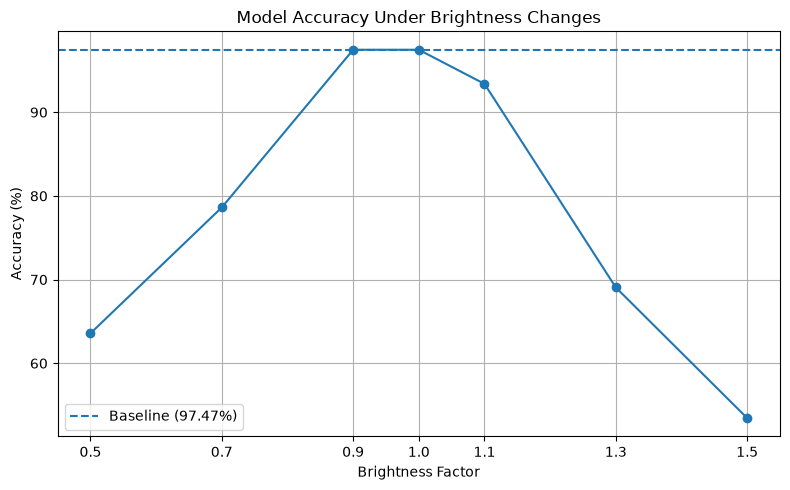

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_brightness_accuracy.png


In [15]:
# Plot and save brightness accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    brightness_results_df["brightness_factor"],
    brightness_results_df["accuracy"] * 100,
    marker="o"
)

plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Brightness Factor")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Brightness Changes")
plt.xticks(brightness_factors)
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save the figure
output_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "drift_brightness_accuracy.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")

In [16]:
import numpy as np

# Noise strengths to test
noise_strengths = [0, 5, 10, 20, 30, 40]

noise_results = []

for strength in noise_strengths:

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        image_path = PROJECT_ROOT / row["processed_filepath"].replace(
            "..\\", ""
        ).replace("\\", "/"
        )

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Convert to NumPy array
        image_array = np.array(image).astype(np.float32)

        # Add Gaussian noise
        if strength > 0:
            noise = np.random.normal(
                loc=0,
                scale=strength,
                size=image_array.shape
            )

            image_array = np.clip(
                image_array + noise,
                0,
                255
            )

        # Convert back to image
        noisy_image = Image.fromarray(
            image_array.astype(np.uint8)
        )

        # Convert to bytes
        buffer = io.BytesIO()
        noisy_image.save(buffer, format="JPEG")
        image_bytes = buffer.getvalue()

        # Predict
        result = predictor.predict(image_bytes)

        predicted_label = 1 if result["is_defective"] else 0
        true_label = int(row["label"])

        if predicted_label == true_label:
            correct += 1

        total += 1

    accuracy = correct / total

    noise_results.append({
        "noise_strength": strength,
        "accuracy": accuracy
    })

    print(
        f"Noise strength {strength}: "
        f"{accuracy:.4%} accuracy "
        f"({correct}/{total})"
    )

noise_results_df = pd.DataFrame(noise_results)

Noise strength 0: 97.4684% accuracy (693/711)
Noise strength 5: 90.8579% accuracy (646/711)
Noise strength 10: 66.9480% accuracy (476/711)
Noise strength 20: 36.8495% accuracy (262/711)
Noise strength 30: 36.8495% accuracy (262/711)
Noise strength 40: 36.8495% accuracy (262/711)


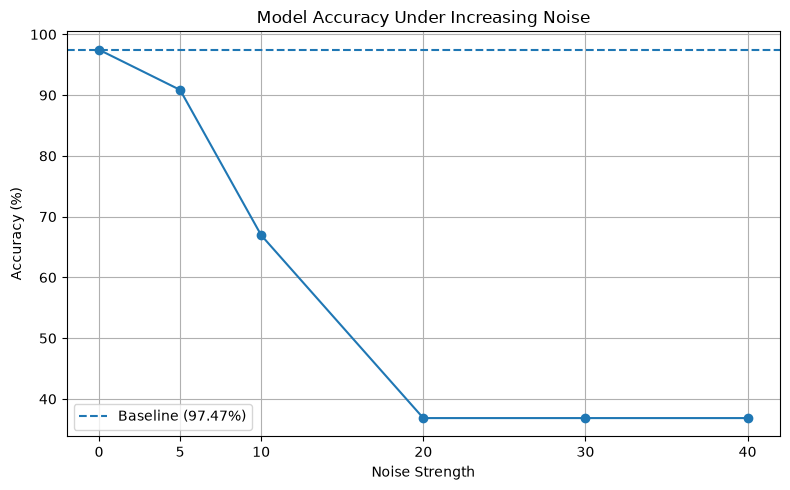

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_noise_accuracy.png


In [17]:
# Plot and save noise accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    noise_results_df["noise_strength"],
    noise_results_df["accuracy"] * 100,
    marker="o"
)

plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Noise Strength")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Increasing Noise")
plt.xticks(noise_strengths)
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save the figure
output_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "drift_noise_accuracy.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")


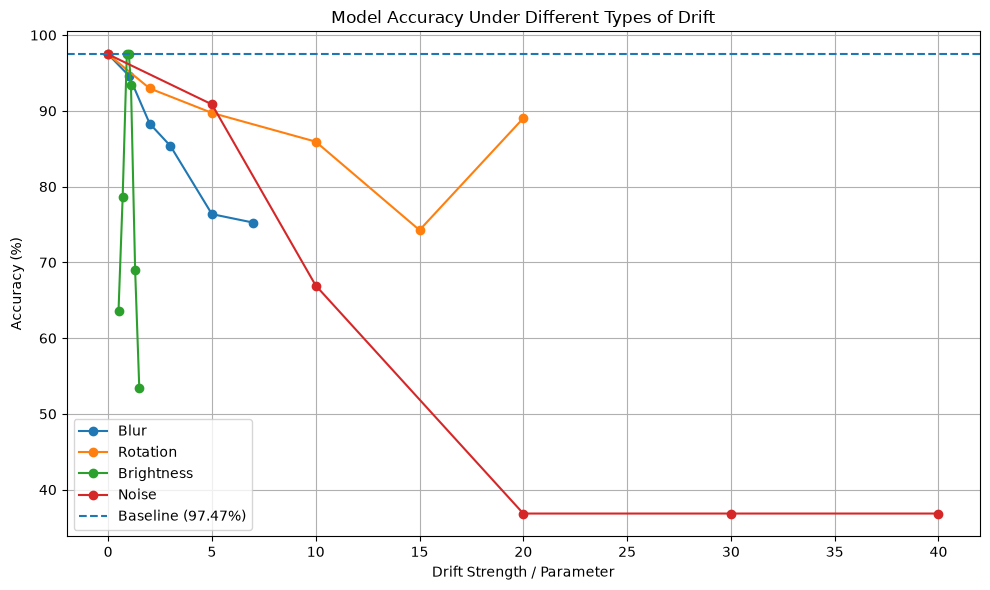

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_comparison.png


In [18]:
# Combined comparison of all drift types

plt.figure(figsize=(10, 6))

# Blur
plt.plot(
    blur_results_df["blur_strength"],
    blur_results_df["accuracy"] * 100,
    marker="o",
    label="Blur"
)

# Rotation
plt.plot(
    rotation_results_df["rotation_angle"],
    rotation_results_df["accuracy"] * 100,
    marker="o",
    label="Rotation"
)

# Brightness
plt.plot(
    brightness_results_df["brightness_factor"],
    brightness_results_df["accuracy"] * 100,
    marker="o",
    label="Brightness"
)

# Noise
plt.plot(
    noise_results_df["noise_strength"],
    noise_results_df["accuracy"] * 100,
    marker="o",
    label="Noise"
)

# Baseline
plt.axhline(
    baseline_accuracy * 100,
    linestyle="--",
    label=f"Baseline ({baseline_accuracy * 100:.2f}%)"
)

plt.xlabel("Drift Strength / Parameter")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Under Different Types of Drift")
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save
output_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "drift_comparison.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")

In [19]:
# Final drift results table

drift_summary = pd.DataFrame({
    "Drift Type": [
        "Blur",
        "Blur",
        "Blur",
        "Blur",
        "Blur",
        "Blur",
        "Rotation",
        "Rotation",
        "Rotation",
        "Rotation",
        "Rotation",
        "Rotation",
        "Brightness",
        "Brightness",
        "Brightness",
        "Brightness",
        "Brightness",
        "Brightness",
        "Brightness",
        "Noise",
        "Noise",
        "Noise",
        "Noise",
        "Noise",
        "Noise"
    ],
    "Strength": (
        blur_results_df["blur_strength"].tolist()
        + rotation_results_df["rotation_angle"].tolist()
        + brightness_results_df["brightness_factor"].tolist()
        + noise_results_df["noise_strength"].tolist()
    ),
    "Accuracy (%)": (
        (blur_results_df["accuracy"] * 100).tolist()
        + (rotation_results_df["accuracy"] * 100).tolist()
        + (brightness_results_df["accuracy"] * 100).tolist()
        + (noise_results_df["accuracy"] * 100).tolist()
    )
})

drift_summary

,Drift Type,Strength,Accuracy (%)
0,Blur,0.0,97.468354
1,Blur,1.0,94.655415
2,Blur,2.0,88.326301
3,Blur,3.0,85.372714
4,Blur,5.0,76.371308
5,Blur,7.0,75.246132
6,Rotation,0.0,97.468354
7,Rotation,2.0,92.967651
8,Rotation,5.0,89.732771
9,Rotation,10.0,85.935302


In [20]:
# Calculate accuracy drop from baseline

drift_summary["Accuracy Drop (percentage points)"] = (
    baseline_accuracy * 100 - drift_summary["Accuracy (%)"]
)

drift_summary

,Drift Type,Strength,Accuracy (%),Accuracy Drop (percentage points)
0,Blur,0.0,97.468354,0.000000
1,Blur,1.0,94.655415,2.812940
2,Blur,2.0,88.326301,9.142053
3,Blur,3.0,85.372714,12.095640
4,Blur,5.0,76.371308,21.097046
5,Blur,7.0,75.246132,22.222222
6,Rotation,0.0,97.468354,0.000000
7,Rotation,2.0,92.967651,4.500703
8,Rotation,5.0,89.732771,7.735584
9,Rotation,10.0,85.935302,11.533052


In [21]:
# Show the worst observed accuracy for each drift type

drift_worst = (
    drift_summary
    .groupby("Drift Type")["Accuracy (%)"]
    .min()
    .reset_index()
    .sort_values("Accuracy (%)")
)

drift_worst

,Drift Type,Accuracy (%)
2,Noise,36.849508
1,Brightness,53.445851
3,Rotation,74.261603
0,Blur,75.246132


In [22]:
# Identify the first tested point where accuracy drops by at least 5 percentage points

threshold = 5.0

degradation_points = []

for drift_type, group in drift_summary.groupby("Drift Type"):

    # Ignore the baseline condition when looking for degradation
    degraded = group[
        (group["Strength"] != 0) &
        (group["Accuracy Drop (percentage points)"] >= threshold)
    ]

    if len(degraded) > 0:
        first_point = degraded.iloc[0]

        degradation_points.append({
            "Drift Type": drift_type,
            "First Tested Significant Drop": first_point["Strength"],
            "Accuracy (%)": first_point["Accuracy (%)"],
            "Drop (percentage points)": first_point[
                "Accuracy Drop (percentage points)"
            ]
        })
    else:
        degradation_points.append({
            "Drift Type": drift_type,
            "First Tested Significant Drop": "Not observed",
            "Accuracy (%)": None,
            "Drop (percentage points)": None
        })

degradation_df = pd.DataFrame(degradation_points)

degradation_df

,Drift Type,First Tested Significant Drop,Accuracy (%),Drop (percentage points)
0,Blur,2.0,88.326301,9.142053
1,Brightness,0.5,63.572433,33.895921
2,Noise,5.0,90.857947,6.610408
3,Rotation,5.0,89.732771,7.735584


In [23]:
# Save the degradation summary for the team

output_path = (
    PROJECT_ROOT
    / "reports"
    / "drift_degradation_summary.csv"
)

degradation_df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\drift_degradation_summary.csv


In [24]:
# Check that all drift figures were saved

figure_paths = [
    PROJECT_ROOT / "reports" / "figures" / "drift_blur_accuracy.png",
    PROJECT_ROOT / "reports" / "figures" / "drift_rotation_accuracy.png",
    PROJECT_ROOT / "reports" / "figures" / "drift_brightness_accuracy.png",
    PROJECT_ROOT / "reports" / "figures" / "drift_noise_accuracy.png",
    PROJECT_ROOT / "reports" / "figures" / "drift_comparison.png",
]

for path in figure_paths:
    print(f"{'✓' if path.exists() else '✗'} {path}")

✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_blur_accuracy.png
✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_rotation_accuracy.png
✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_brightness_accuracy.png
✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_noise_accuracy.png
✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\figures\drift_comparison.png


In [25]:
summary_path = PROJECT_ROOT / "reports" / "drift_degradation_summary.csv"

print(f"{'✓' if summary_path.exists() else '✗'} {summary_path}")

degradation_df

✓ c:\Users\HP\Documents\GitHub\ml-engineering-miniproject\reports\drift_degradation_summary.csv


,Drift Type,First Tested Significant Drop,Accuracy (%),Drop (percentage points)
0,Blur,2.0,88.326301,9.142053
1,Brightness,0.5,63.572433,33.895921
2,Noise,5.0,90.857947,6.610408
3,Rotation,5.0,89.732771,7.735584
